# 1. Import the libraries:

In [172]:
import os
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder, RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [173]:
# os.chdir("../")
%pwd

'D:\\ML and AI Engineer\\Projects\\An-end-to-end-customer-churn-prediction-model'

### Load the data:

In [174]:
clipped_train = pd.read_parquet("Artifacts/feature_engineering/data_clipped/train.parquet")
clipped_test = pd.read_parquet("Artifacts/feature_engineering/data_clipped/test.parquet")

unclipped_train = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/train.parquet")
unclipped_test = pd.read_parquet("Artifacts/feature_engineering/data_unclipped/test.parquet")

In [175]:
clipped_train.head(1)

,customerid,order_frequency,total_monetary_value,total_quantity_abs,total_order_issues,country,avg_order_value,avg_quantity_per_order,customer_order_issue_rate,recency,tenure,avg_stockcode_issue_rate,max_stockcode_issue_rate,total_orders_made_for_stock,churn
0,12346.0,13,187.91,81,10,United Kingdom,14.454615,6.230769,0.769231,177,471,0.087973,1.041667,6767,1


# 2. Using the clipped data for the experimentation:

In [176]:
clipped_train.isna().sum()

customerid                     0
order_frequency                0
total_monetary_value           0
total_quantity_abs             0
total_order_issues             0
country                        0
avg_order_value                0
avg_quantity_per_order         0
customer_order_issue_rate      0
recency                        0
tenure                         0
avg_stockcode_issue_rate       0
max_stockcode_issue_rate       0
total_orders_made_for_stock    0
churn                          0
dtype: int64

## 2.1 Define the dependent and independent features:

In [177]:
def create_dep_indep_features(df:pd.DataFrame):
    """
    Splits the data into dependent(y) and independent(X) features:
    """
    X = df.drop(columns=['customerid', 'churn'])
    y = df['churn']
    return X, y
    
    

In [178]:
X_train, y_train = create_dep_indep_features(df=clipped_train)
X_test, y_test = create_dep_indep_features(df=clipped_test)

## 2.2 Define the column groups:

In [179]:
# For numerical features:
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# For categorical features:
categorical_features = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

In [180]:
numerical_features

['order_frequency',
 'total_monetary_value',
 'total_quantity_abs',
 'total_order_issues',
 'avg_order_value',
 'avg_quantity_per_order',
 'customer_order_issue_rate',
 'recency',
 'tenure',
 'avg_stockcode_issue_rate',
 'max_stockcode_issue_rate',
 'total_orders_made_for_stock']

In [181]:
categorical_fetaures

['country']

## 2.3 Scaling the features:

For scaling numerical features, we have these options:
1. Min-max scaler
2. Standardization
3. RobustScaler

But, to use standardization, it is important to have features that follow a normal-dirstribution for a better results, below,
none of the features follow a normal/gaussian distribution, so, i will be testing out both the sacling techniques, and later finalize the method based on the model's performance on the testing set.

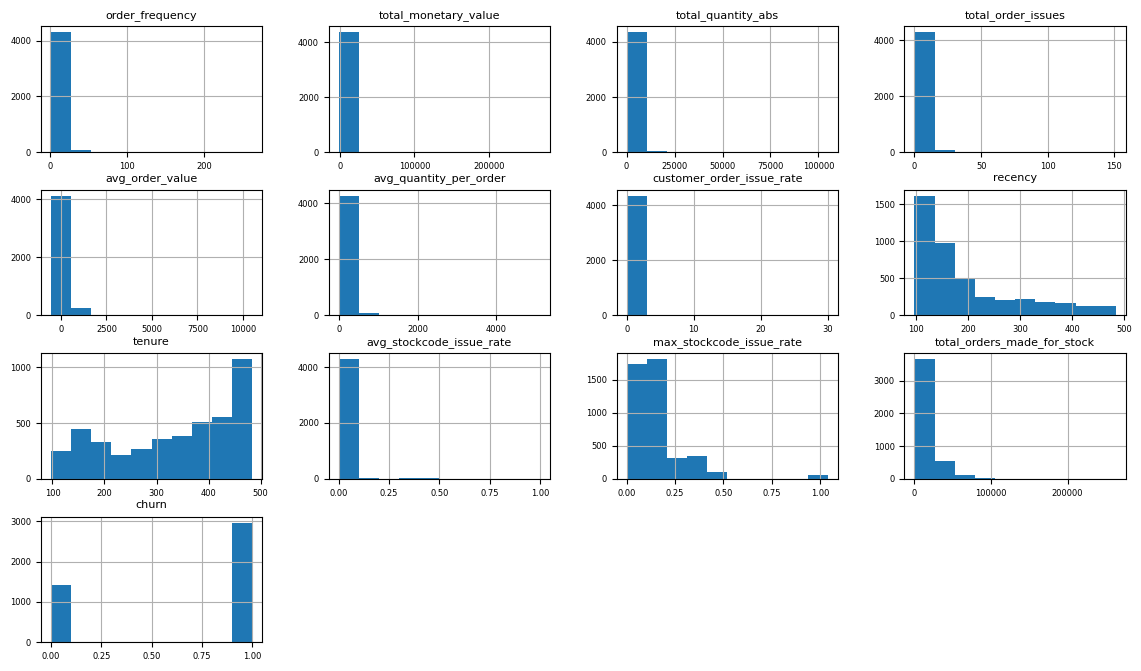

In [185]:
fig = clipped_train.hist(xlabelsize=6, ylabelsize=6, figsize=(14, 8))
[x.title.set_size(8) for x in fig.ravel()]
plt.show()

In [187]:
clipped_train.groupby('churn').size()

churn
0    1413
1    2967
dtype: int64

### 1. Testing with `StandardScaler()` with `KNN()`:

with `SMOTE()`:

In [183]:
std_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_fetaures)
])

pipeline = ImbPipeline([
    ('data_preparation', std_preprocessor), 
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), on test data, the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: 73.16% and the STD is: 1.94%.
With StandardScaler(), on test data, the accuracy: 68.67% | precision: 79.04 | recall: 74.48% | and F1-score: 76.70% 


In [184]:
std_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_fetaures)
])

pipeline = Pipeline([
    ('data_preparation', std_preprocessor), 
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")


pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), on test data, the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'StandardScaler() and OneHotEncoder()', on training data the mean f1-score is: 81.36% and the STD is: 1.35%.
With StandardScaler(), on test data, the accuracy: 74.02% | precision: 76.35 | recall: 90.49% | and F1-score: 82.82% 


### 2. Testing with `MinMaxScaler()` with `KNN()`:

In [162]:
min_max_procesor = ColumnTransformer([
    ('num', MinMaxScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_fetaures)
])

pipeline = Pipeline([
    ('data_preparation', min_max_procesor),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'MinMaxScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'MinMaxScaler() and OneHotEncoder()', the mean score is: 72.79% and the STD is: 1.99%.
With StandardScaler(), the accuracy: 73.51% | precision: 76.02 | recall: 90.18% | and F1-score: 82.49% 


### 3. Testing with `RobustScaler()`with `KNN()`:

In [163]:
robust_preprocess = ColumnTransformer([
    ('num', RobustScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_fetaures)
])

pipeline = Pipeline([
    ('data_preparation', robust_preprocess),
    ('clf', KNeighborsClassifier())
])


cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"With 'RobustScaler() and OneHotEncoder()', the mean score is: {np.mean(n_scores)*100:.2f}% and the STD is: {np.std(n_scores)*100:.2f}%.")

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(f"With StandardScaler(), the accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% |"
     f" precision: {precision_score(y_test, y_pred)*100:.2f} | recall: {recall_score(y_test, y_pred)*100:.2f}% |",
     f"and F1-score: {f1_score(y_test, y_pred)*100:.2f}% ")

With 'RobustScaler() and OneHotEncoder()', the mean score is: 74.61% and the STD is: 1.99%.
With StandardScaler(), the accuracy: 74.75% | precision: 76.56 | recall: 91.54% | and F1-score: 83.38% 


## 2.4 Feature Selection:

In [159]:
clipped_train['churn'].value_counts()

churn
1    2967
0    1413
Name: count, dtype: int64